'住宅' に関する統計データが 5 件見つかりました。


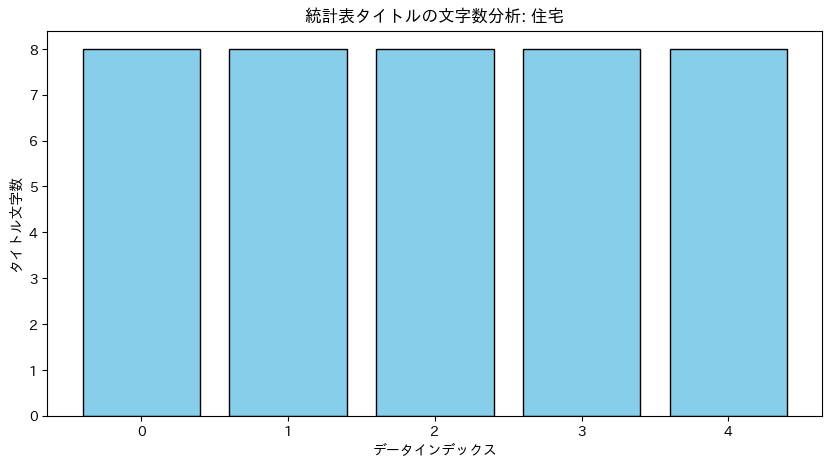

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォントの設定
try:
    import japanize_matplotlib
except ImportError:
    # japanize_matplotlib がない場合は標準フォントを使用
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meiryo', 'IPAexGothic', 'sans-serif']

# --- A. データの読み込み (課題要件: DBクエリの利用) ---
def load_data_from_db():
    # フォルダ構造に合わせてパスを調整 (Notebookがfinal-task内にある場合)
    db_path = "../estat_real_estate.db"
    conn = sqlite3.connect(db_path)
    # SQLクエリを発行してデータを取得
    query = "SELECT * FROM ward_stats"
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# --- B. 動的な分析関数 (課題要件: 関数・クラスの利用) ---
def analyze_by_keyword(df, keyword):
    """
    キーワードに基づいて統計情報をフィルタリングし、可視化する動的関数
    """
    filtered_df = df[df['title'].str.contains(keyword)].copy()
    
    if filtered_df.empty:
        print(f"キーワード '{keyword}' に一致するデータは見つかりませんでした。")
        return

    print(f"'{keyword}' に関する統計データが {len(filtered_df)} 件見つかりました。")
    
    # タイトルの文字数を分析指標として計算
    filtered_df['title_len'] = filtered_df['title'].apply(len)
    
    # グラフの描画
    plt.figure(figsize=(10, 5))
    plt.bar(filtered_df.index, filtered_df['title_len'], color='skyblue', edgecolor='black')
    plt.title(f"統計表タイトルの文字数分析: {keyword}")
    plt.xlabel("データインデックス")
    plt.ylabel("タイトル文字数")
    plt.show()

# --- C. 実行処理 ---
data = load_data_from_db()
analyze_by_keyword(data, "住宅")

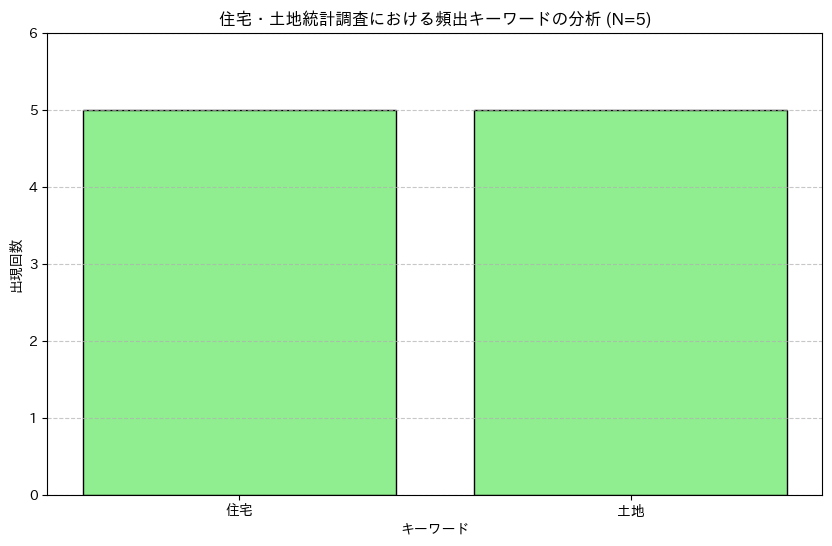

In [5]:
import collections

def analyze_keywords_in_titles(df, keyword_to_search="住宅"):
    """
    (データサイエンス的な考察)
    """
    # 1. タイトル内のキーワード出現頻度をカウント
    titles = df['title'].tolist()

    # 定義したいキーワード
    target_keywords = ["住宅", "土地", "世帯", "借家", "賃貸"]
    keyword_counts = collections.defaultdict(int)
    
    for title in titles:
        for word in target_keywords:
            if word in title:
                keyword_counts[word] += 1
    
    # 2. データフレームに変換
    analysis_df = pd.DataFrame(list(keyword_counts.items()), columns=['キーワード', '出現回数'])
    
    if analysis_df.empty:
        print("分析対象のキーワードが見つかりませんでした。")
        return

    # 3. グラフの描画
    plt.figure(figsize=(10, 6))
    plt.bar(analysis_df['キーワード'], analysis_df['出現回数'], color='lightgreen', edgecolor='black')
    plt.title(f"住宅・土地統計調査における頻出キーワードの分析 (N={len(df)})")
    plt.xlabel("キーワード")
    plt.ylabel("出現回数")
    plt.ylim(0, max(analysis_df['出現回数']) + 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 執行分析
analyze_keywords_in_titles(data)